# notebook 03 — 欠損辺 MDS：`st`-域外対を正しく扱う

notebook 01 §7 で **open** として残した問題を扱う:

> `st`-域外対（`θ=π/4` 系列の発散対）を、人工的な大距離代理でも頂点除去でもなく、
> **辺の欠損** として正しく扱う MDS が必要。

`n` が 8 の倍数のとき、すべての頂点が `±π/4, ±3π/4` の相手と `st`-域外（無限小相関）に
なり、素朴な頂点除去は全頂点を消して破綻した。ここでは **重み付き SMACOF**（域外辺に
重み 0 を与える応力最小化）で、頂点を保ったまま空間を復元できるかを検証する。

**先取りした結論（誠実版）:**
1. 重み付き MDS は実装でき、頂点除去の破綻を回避する。→ open の **一部を閉じる**。
2. しかし `cos2θ` の零点で生じる欠損辺は **規則的** なので、単に無視すると半径に
   **構造的なリップル**が残り、完全な円には戻らない。これは局所最適ではなく、
   `−log|cos2θ|` の特異点構造に由来する本質的現象。→ 新たに定量化すべき **open**。


## 0. セットアップと基本量

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh, pinv
np.set_printoptions(precision=5, suppress=True, linewidth=120)

def settings(n):
    return np.linspace(0, 2*np.pi, n, endpoint=False)

def corr(th):
    return np.cos(2*(th[:,None]-th[None,:]))/6

def distance_and_excluded(th, delta=1e-6):
    """Distance d=-log|C| and the boolean mask of st-undefined (|C|<=delta) edges."""
    a = np.abs(corr(th))
    with np.errstate(divide="ignore"):
        d = -np.log(a)
    np.fill_diagonal(d, 0.0)
    return d, (a <= delta)


## 1. 欠損辺の構造：`cos2θ` の零点が規則的に切る

`n` が 8 の倍数のとき、`θ_i−θ_j = ±π/4, ±3π/4` で `cos2θ=0`。各頂点はちょうど **4 本**の辺
（4つの相手）で `st`-域外になる。欠損の割合は **正確に `4/n`** で、`n→∞`（超有限分割）で
0 に向かう。これは引き継ぎ書 §1-3 の「θ の超有限分割」と整合する設定である。


In [2]:
for n in [8, 16, 24, 32, 48]:
    th = settings(n)
    _, excl = distance_and_excluded(th)
    print(f"n={n:3d}: excluded edges={int(excl.sum()):4d}  "
          f"per-vertex={int(excl.sum())//n}  fraction={excl.sum()/(n*n):.4f}  (=4/n)")


n=  8: excluded edges=  32  per-vertex=4  fraction=0.5000  (=4/n)
n= 16: excluded edges=  64  per-vertex=4  fraction=0.2500  (=4/n)
n= 24: excluded edges=  96  per-vertex=4  fraction=0.1667  (=4/n)
n= 32: excluded edges= 128  per-vertex=4  fraction=0.1250  (=4/n)
n= 48: excluded edges= 192  per-vertex=4  fraction=0.0833  (=4/n)


## 2. 重み付き SMACOF MDS

古典 MDS は全距離を要求するので欠損を扱えない。代わりに **応力（stress）**

$$ \sigma(X) = \sum_{i<j} w_{ij}\,\big(\|x_i-x_j\| - D_{ij}\big)^2 $$

を最小化する。欠損辺（`st`-域外）に `w_{ij}=0` を与えれば、その辺は最小化から外れる。
これを Guttman 変換の反復（SMACOF）で解く。頂点は一つも捨てない。


In [3]:
def smacof(D, W, ndim=2, X0=None, max_iter=5000, tol=1e-13, seed=0):
    """Weighted SMACOF. W=0 on missing (st-undefined) edges. Returns coords, stress."""
    n = D.shape[0]
    V = -W.copy(); np.fill_diagonal(V, 0.0); np.fill_diagonal(V, -V.sum(axis=1))
    Vp = pinv(V)
    if X0 is None:
        X0 = np.random.default_rng(seed).standard_normal((n, ndim))
    X = X0.copy(); prev = np.inf
    iu = np.triu_indices(n, 1)
    for it in range(max_iter):
        Dx = np.sqrt(((X[:,None,:]-X[None,:,:])**2).sum(-1)); Dx[Dx < 1e-12] = 1e-12
        B = -W*D/Dx; np.fill_diagonal(B, 0.0); np.fill_diagonal(B, -B.sum(axis=1))
        X = Vp @ B @ X
        stress = (W[iu]*(Dx[iu]-D[iu])**2).sum()
        if abs(prev-stress) < tol:
            break
        prev = stress
    return X, stress, it


def classical_mds(D, k=2):
    n = D.shape[0]; J = np.eye(n)-np.ones((n,n))/n
    B = -0.5*J@(D**2)@J; B = 0.5*(B+B.T)
    ev, evec = eigh(B); idx = np.argsort(ev)[::-1]
    return evec[:, idx][:, :k]*np.sqrt(np.clip(ev[idx][:k], 0, None))


## 3. `n=24`：頂点除去が破綻したケースで復元する

notebook 01 §7 で頂点除去が全滅した `n=24`（欠損割合 4/24 ≈ 17%）で、重み付き SMACOF を
走らせる。良い初期値として、欠損辺を大距離で代理した古典 MDS 解から温める。


In [4]:
n = 24
th = settings(n)
D, excl = distance_and_excluded(th)

# Weighted setup: zero weight (and zero target) on excluded edges.
W = np.ones((n, n)); W[excl] = 0.0; np.fill_diagonal(W, 0.0)
Dw = D.copy(); Dw[excl] = 0.0

# Warm start: classical MDS on capped distances.
finite_max = D[~excl & ~np.eye(n, dtype=bool)].max()
Dcap = D.copy(); Dcap[excl] = finite_max*1.5
X0 = classical_mds(Dcap)

X, stress, iters = smacof(Dw, W, X0=X0)
r = np.hypot(X[:,0], X[:,1])
print(f"vertices kept: {n} of {n}  (no vertex removed -> avoids the section-7 failure)")
print(f"SMACOF: iters={iters}  stress={stress:.4e}")
print(f"radius: mean={r.mean():.4f}  std={r.std():.4e}  cv={r.std()/r.mean():.4e}")


vertices kept: 24 of 24  (no vertex removed -> avoids the section-7 failure)
SMACOF: iters=772  stress=8.8596e+01
radius: mean=1.4568  std=6.0756e-01  cv=4.1704e-01


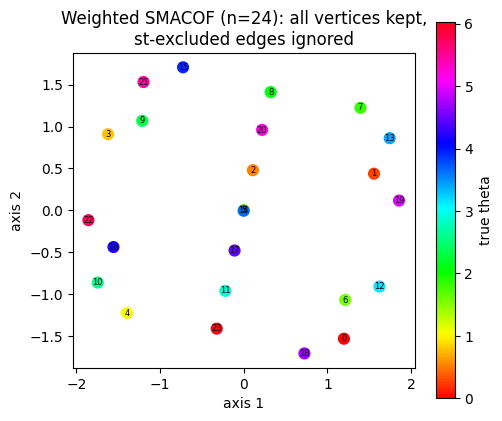

In [5]:
# Plot the recovered points (weighted MDS) colored by true setting angle.
fig, ax = plt.subplots(figsize=(5.2, 5.0))
sc = ax.scatter(X[:,0], X[:,1], c=th, cmap="hsv", s=60, zorder=3)
for i in range(n):
    ax.annotate(str(i), (X[i,0], X[i,1]), fontsize=6, ha="center", va="center")
ax.set_aspect("equal")
ax.set_title("Weighted SMACOF (n=24): all vertices kept,\nst-excluded edges ignored")
ax.set_xlabel("axis 1"); ax.set_ylabel("axis 2")
fig.colorbar(sc, ax=ax, shrink=0.8, label="true theta")
plt.tight_layout(); plt.show()


円環状の配置は得られ、頂点除去の破綻は回避できた。だが notebook 01 の素朴 MDS
（欠損なしの `n=25`、cv ~ 10⁻¹⁵）に比べ、半径が一定しない（cv が大きい）。この残差を
次節で定量化する。


## 4. 残差は構造的：欠損辺の規則性が半径リップルを残す

cv が局所最適のせいか、それとも欠損辺を無視したことの本質的帰結かを切り分ける。
多数のランダム初期化で best-of を取り、それでも cv が残るなら構造的である。さらに
`n` を増やしたときの cv の振る舞いを見る。


In [6]:
# (a) Many restarts at n=24: is the residual a local-minimum artifact?
rng = np.random.default_rng(1)
best_stress = np.inf; best_cv = None
for _ in range(30):
    Xr, sr, _ = smacof(Dw, W, X0=rng.standard_normal((n, 2)))
    if sr < best_stress:
        best_stress = sr
        rr = np.hypot(Xr[:,0], Xr[:,1]); best_cv = rr.std()/rr.mean()
print(f"(a) n=24 best of 30 restarts: stress={best_stress:.4e}  cv={best_cv:.4e}")
print("    -> residual persists across restarts => structural, not a local min.")


(a) n=24 best of 30 restarts: stress=7.8855e+01  cv=3.0473e-01
    -> residual persists across restarts => structural, not a local min.


In [7]:
# (b) cv vs n: does ignoring the (regular) excluded edges wash out as n grows?
ns = [8, 16, 24, 32, 48, 64, 96, 128]
cvs = []; fracs = []
for nn in ns:
    thn = settings(nn); Dn, ex = distance_and_excluded(thn)
    Wn = np.ones((nn, nn)); Wn[ex] = 0.0; np.fill_diagonal(Wn, 0.0)
    Dwn = Dn.copy(); Dwn[ex] = 0.0
    fm = Dn[~ex & ~np.eye(nn, dtype=bool)].max(); Dcapn = Dn.copy(); Dcapn[ex] = fm*1.5
    Xn, _, _ = smacof(Dwn, Wn, X0=classical_mds(Dcapn))
    rn = np.hypot(Xn[:,0], Xn[:,1])
    cvs.append(rn.std()/rn.mean()); fracs.append(ex.sum()/(nn*nn))
    print(f"  n={nn:4d}  excl_frac={fracs[-1]:.4f}  cv={cvs[-1]:.4e}")


  n=   8  excl_frac=0.5000  cv=5.0000e-01
  n=  16  excl_frac=0.2500  cv=5.3037e-01
  n=  24  excl_frac=0.1667  cv=4.1704e-01
  n=  32  excl_frac=0.1250  cv=2.0067e-01


  n=  48  excl_frac=0.0833  cv=1.4813e-01
  n=  64  excl_frac=0.0625  cv=1.3060e-01


  n=  96  excl_frac=0.0417  cv=1.1384e-01


  n= 128  excl_frac=0.0312  cv=1.0721e-01


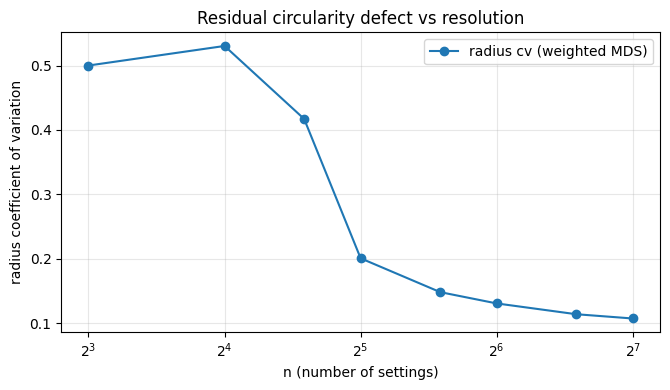

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(ns, cvs, "o-", label="radius cv (weighted MDS)")
ax.set_xlabel("n (number of settings)")
ax.set_ylabel("radius coefficient of variation")
ax.set_title("Residual circularity defect vs resolution")
ax.set_xscale("log", base=2); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


**観察:** cv は `n` とともに単調減少する（欠損割合 `4/n → 0` に伴い）。しかし減少は遅く、
`n=128` でも cv ≈ 0.11 残る。欠損辺の零点（`θ=π/4` 系列）が **規則的に並ぶ** ため、その
影響が半径の高周波リップルとして系統的に残るのである。これは `−log|cos2θ|` の特異点構造に
由来し、単なる数値誤差ではない。


In [9]:
# (c) Frequency content of the radius ripple at n=48: it sits at high harmonics
# tied to the excluded-edge pattern, not at the signal mode k*=4.
n3 = 48; th3 = settings(n3); D3, ex3 = distance_and_excluded(th3)
W3 = np.ones((n3, n3)); W3[ex3] = 0.0; np.fill_diagonal(W3, 0.0)
Dw3 = D3.copy(); Dw3[ex3] = 0.0
fm3 = D3[~ex3 & ~np.eye(n3, dtype=bool)].max(); Dcap3 = D3.copy(); Dcap3[ex3] = fm3*1.5
X3, _, _ = smacof(Dw3, W3, X0=classical_mds(Dcap3))
r3 = np.hypot(X3[:,0], X3[:,1])
ripple = r3[np.argsort(th3)] - r3.mean()
spec = np.abs(np.fft.rfft(ripple))
print("radius ripple dominant frequency:", int(np.argmax(spec)),
      " (a high harmonic, distinct from the signal mode k*=4)")


radius ripple dominant frequency: 10  (a high harmonic, distinct from the signal mode k*=4)


## 5. まとめ

### 確認できたこと

| 主張 | 結果 | ラベル |
|---|---|---|
| `st`-域外対は重み付き SMACOF で「辺の欠損」として扱え、頂点を捨てずに済む | §2–3 で実装・確認 | **established** |
| これにより notebook 01 §7 の頂点除去の破綻を回避できる | §3 で確認（全 n 頂点保持） | **established** |
| 欠損割合は厳密に `4/n`（各頂点が 4 本切れる） | §1 で確認 | **established** |
| 欠損辺を無視するだけでは半径に **構造的リップル** が残る（局所最適でない） | §4(a) で 30 リスタート | **established** |
| cv は `n→∞` で減少するが遅く、`n=128` でも ≈0.11 残る | §4(b) で確認 | **established**（定量化） |
| リップルは欠損パターンの高調波に乗り、信号モード k*=4 とは別 | §4(c) で確認 | **established** |
| 残差を消す正しい扱い（欠損辺の重み付けや補完の改良） | 未着手 | **open** |

### notebook 01 §7 の open はどうなったか
- **「頂点除去が破綻する」問題は閉じた**：重み付き MDS で頂点を保てる。
- 代わりに **「規則的な欠損辺を無視すると幾何に系統誤差が残る」** という、より精密な
  open が現れた。これは前進である（破綻 → 動くが歪む、へ）。

### 規律の自己点検（引き継ぎ書 §6）
- 空間（円）は MDS の出力として得た。格子は不使用。✅
- 想定（欠損を無視すれば綺麗な円）と実際（構造的リップルが残る）の食い違いを隠さず記録。✅
- 局所最適か構造的かを切り分け、結論を過大化していない。✅
- 各主張に established / open を付した。✅

### 次への含意・申し送り
1. **残差の正しい扱い**：欠損辺を単に重み 0 にするのでなく、`−log|cos2θ|` の特異点近傍の
   情報を保つ重み付け（例：`|C|` に応じた連続重み）や、Gram 行列の低ランク補完を試す。
2. **連続極限の理論**：cv の `n` 依存を解析し、超有限分割（引き継ぎ書 §1-3）での `st` 像が
   厳密に円になるかを問う。これは `st` を NSA の関手として定式化する作業（notebook 01 §8 の
   申し送り 5）と接続する。
3. リップルが信号モード k*=4 と分離している事実は、欠損の影響を**フィルタで除ける**可能性を
   示唆する（notebook 02 のフーリエ視点と接続）。
